In [26]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors

In [27]:
# ==============================
# PARÂMETROS GERAIS
# ==============================

L = 100
n_lagartos = L**2
estrategias = ['O', 'Y', 'B']

a = 2
b = 1/a

matriz_payoff = np.array([[1, b, a],
                          [a, 1, b],
                          [b, a, 1]])

index_map = {'O': 0, 'Y': 1, 'B': 2}

n_geracoes = 100
n_pop = 1
A = 0.05
wO = 0.25
wB = 0.5
wY = 0.5


output_dir = output_dir = f"C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/Montecarlo_sobreposicao_geracao/vizinhanca_homogenea/"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# ==============================
# CLASSE LAGARTO
# ==============================

class Lagarto:
    def __init__(self, i, j, raio, estrategia, fitness,
                 coord_vizinhos, coord_vizinhanca_extendida,
                 estrategia_vizinhanca_extendida, n_vizinhos):
        self.i = i
        self.j = j
        self.raio = raio
        self.estrategia = estrategia
        self.fitness = 0
        self.coord_vizinhos = []
        self.coord_vizinhanca_extendida = []
        self.estrategia_vizinhanca_extendida = []
        self.n_vizinhos = 0

    def calcular_coord_vizinhos(self, L):
        r = self.raio

        lista_vizinhos = []
        for dx in range(-r, r+1):
            for dy in range(-r, r+1):
                if abs(dx) + abs(dy) <= r and not (dx == 0 and dy == 0): #Von neuman
                #if not (dx == 0 and dy == 0):
                    ni = (self.i + dx) % L
                    nj = (self.j + dy) % L
                    lista_vizinhos.append((ni, nj))
        self.coord_vizinhos = lista_vizinhos

    def calcular_n_vizinhos(self):
      self.n_vizinhos = len(self.coord_vizinhos) + len(self.coord_vizinhanca_extendida)

    def mortalidade(self, A, w):
        return 1 / (1 + A * np.exp(w * self.fitness))

    def calcular_fitness(self, mapa):
        fitness_total = 0
        todos_vizinhos = set(self.coord_vizinhos + self.coord_vizinhanca_extendida)
        for ni, nj in todos_vizinhos:
            vizinho = mapa.get((ni, nj))
            if vizinho is not None:
                fitness_total += matriz_payoff[index_map[self.estrategia], index_map[vizinho.estrategia]]
        self.fitness = fitness_total
    
    def ajustar_vizinhos_reciprocos(self, mapa): 
        self.coord_vizinhanca_extendida = []
        self.estrategia_vizinhanca_extendida = []
        
        for (ni, nj) in self.coord_vizinhos: 
                vizinho = mapa[(ni, nj)]
                if (self.i, self.j) not in vizinho.coord_vizinhos:
                    vizinho.estrategia_vizinhanca_extendida.append(str(self.estrategia))
                    vizinho.coord_vizinhanca_extendida.append((self.i, self.j))
                    print(f"Ajustando vizinho recíproco: Lagarto ({self.i}, {self.j}) adiciona ({ni}, {nj}) como vizinho estendido")

# ==============================
# FUNÇÕES AUXILIARES
# ==============================

def criar_lagartos():
    lista = []
    for i in range(L):
        for j in range(L):
            estrategia = np.random.choice(estrategias)
            if estrategia == 'O':
                raio = 1
            elif estrategia == 'Y':
                raio = 1
            else:
                raio = 1
            lista.append(Lagarto(i, j, raio, estrategia, 0, [], [], [], 0))
    return lista

def calcular_freq(matriz):
    return np.array([np.sum(matriz == s) / (L**2) for s in estrategias])

def media_vizinhos(lista_lagartos):
    return np.mean([l.n_vizinhos for l in lista_lagartos])

def media_vizinhos_por_estrategia(lista_lagartos):
    medias = []
    for e in estrategias:
        raios = [l.n_vizinhos for l in lista_lagartos if l.estrategia == e]
        medias.append(np.mean(raios) if len(raios) > 0 else np.nan)
    return medias

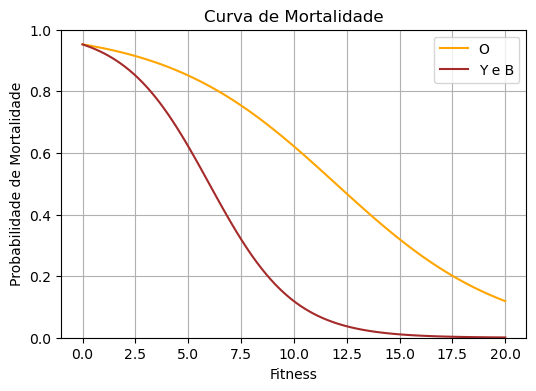

In [32]:
def mortalidade(fitness, A, w):
    return 1 / (1 + A * np.exp(w * fitness))

plt.figure(figsize=(6, 4))
x = np.linspace(0, 20, 100)
y0 = mortalidade(x, A = 0.05, w = 0.25)
y1 = mortalidade(x, A = 0.05, w = 0.5)
plt.plot(x, y0, color = 'orange', label = 'O')
plt.plot(x, y1, color = 'brown', label = 'Y e B')
#plt.plot(x, y2)
#plt.plot(x, y3)
#plt.plot(x, y4)
plt.xlabel('Fitness')
plt.ylabel('Probabilidade de Mortalidade')
plt.title('Curva de Mortalidade')
plt.ylim(0,1)
plt.legend()
plt.grid()
plt.show()

In [33]:
# ==============================
# SIMULAÇÃO
# ==============================

def simulacao(A, wO, wY, wB, seed=None):

    resultados = []

    for pop in range(n_pop):

        if seed is not None:
            np.random.seed(seed + pop)

        lista_lagartos = criar_lagartos()
        mapa = {(l.i, l.j): l for l in lista_lagartos}

        matriz_posicao = np.empty((L, L), dtype=object)
        for l in lista_lagartos:
            matriz_posicao[l.i, l.j] = l.estrategia

        freq = calcular_freq(matriz_posicao)
        vizinhos_mean = media_vizinhos(lista_lagartos)
        r_por_estrat = media_vizinhos_por_estrategia(lista_lagartos)
        resultados.append({
            "pop": pop,
            "t": -1,
            "freq_O": freq[0],
            "freq_Y": freq[1],
            "freq_B": freq[2],
            "vizinhos_mean": vizinhos_mean,
            "vizinhos_mean_O": r_por_estrat[0],
            "vizinhos_mean_Y": r_por_estrat[1],
            "vizinhos_mean_B": r_por_estrat[2],
        })

        for t in range(n_geracoes):
            print(f"População {pop+1} - Geração {t+1}/{n_geracoes}")

            for _ in range(L * L): # faz o sorteio de L^2 células para completar uma geração
                i = np.random.randint(0, L)
                j = np.random.randint(0, L)
                lagarto = mapa[(i, j)] # lagarto sorteado
                
                lagarto.calcular_coord_vizinhos(L) # define os vizinhos do lagarto sorteado                
                #lagarto.ajustar_vizinhos_reciprocos(mapa) # ajusta os vizinhos recíprocos do lagarto sorteado
                lagarto.calcular_n_vizinhos()
                lagarto.calcular_fitness(mapa) # calcula o fitness apenas do lagarto sorteado
                
                if lagarto.estrategia == 'O':
                    d = lagarto.mortalidade(A, wO)
                elif lagarto.estrategia == 'Y':
                    d = lagarto.mortalidade(A, wY)
                else:
                    d = lagarto.mortalidade(A, wB)
                
                if np.random.rand() > d: # se o número sorteado for maior que a probabilidade de mortalidade, o lagarto sobrevive e mantém sua estratégia
                    pass
                else: # se o lagarto morrer, ele adota a melhor estratégia entre seus vizinhos
                    maior_fitness = 0

                    for (ni, nj) in lagarto.coord_vizinhos: # olha pros vizinhos do lagarto sorteado
                        vizinho = mapa[(ni, nj)]
                        vizinho.calcular_coord_vizinhos(L) # define os vizinhos do vizinho
                        #vizinho.ajustar_vizinhos_reciprocos(mapa) # ajusta os vizinhos recíprocos do vizinho
                        vizinho.calcular_n_vizinhos()
                        vizinho.calcular_fitness(mapa) # pega o fitness do vizinho

                        if vizinho.fitness <= 0:
                            print("Erro, fitness é:", vizinho.fitness)

                        if vizinho.fitness > maior_fitness: # se o fitness do vizinho for maior que o maior_fitness encontrado até agora, atualiza o maior_fitness e a melhor_estratégia
                            maior_fitness = vizinho.fitness
                            melhor_estrategia = vizinho.estrategia
                            melhor_raio = vizinho.raio
                        elif vizinho.fitness == maior_fitness: # se for igual, sorteia entre manter a melhor estratégia atual ou adotar a do vizinho
                            a = np.random.rand()
                            if a < 0.5:
                                melhor_estrategia = vizinho.estrategia
                                melhor_raio = vizinho.raio
                            else:
                                pass
                        else: # se for menor, mantém a melhor estratégia atual
                            pass

                    lagarto.estrategia = melhor_estrategia # adota a melhor estratégia encontrada entre os vizinhos           
                    lagarto.raio = melhor_raio # adota o melhor raio encontrado entre os vizinhos

            for l in lista_lagartos:
                matriz_posicao[l.i, l.j] = l.estrategia

            t += 1

            freq = calcular_freq(matriz_posicao)
            vizinhos_mean = media_vizinhos(lista_lagartos)
            r_por_estrat = media_vizinhos_por_estrategia(lista_lagartos)

            resultados.append({
                "pop": pop,
                "t": t,
                "freq_O": freq[0],
                "freq_Y": freq[1],
                "freq_B": freq[2],
                "vizinhos_mean": vizinhos_mean,
                "vizinhos_mean_O": r_por_estrat[0],
                "vizinhos_mean_Y": r_por_estrat[1],
                "vizinhos_mean_B": r_por_estrat[2],
            })

    return pd.DataFrame(resultados)


# ==============================
# RODAR
# ==============================

df = simulacao(A = A, wO = wO, wY = wY, wB = wB, seed = 1)
df.to_csv(os.path.join(output_dir, "resultados.csv"), index=False)

print("Simulação concluída.")

População 1 - Geração 1/100
População 1 - Geração 2/100
População 1 - Geração 3/100
População 1 - Geração 4/100
População 1 - Geração 5/100
População 1 - Geração 6/100
População 1 - Geração 7/100
População 1 - Geração 8/100
População 1 - Geração 9/100
População 1 - Geração 10/100
População 1 - Geração 11/100
População 1 - Geração 12/100
População 1 - Geração 13/100
População 1 - Geração 14/100
População 1 - Geração 15/100
População 1 - Geração 16/100
População 1 - Geração 17/100
População 1 - Geração 18/100
População 1 - Geração 19/100
População 1 - Geração 20/100
População 1 - Geração 21/100
População 1 - Geração 22/100
População 1 - Geração 23/100
População 1 - Geração 24/100
População 1 - Geração 25/100
População 1 - Geração 26/100
População 1 - Geração 27/100
População 1 - Geração 28/100
População 1 - Geração 29/100
População 1 - Geração 30/100
População 1 - Geração 31/100
População 1 - Geração 32/100
População 1 - Geração 33/100
População 1 - Geração 34/100
População 1 - Geração 3

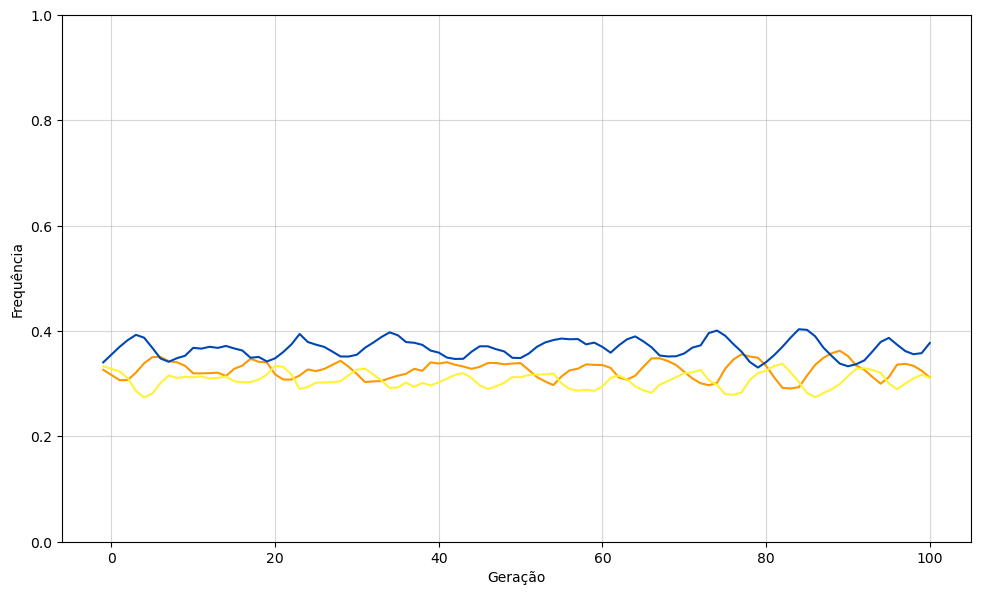

In [34]:
cores = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

df_mean = df.groupby('t').mean().reset_index()
df_sd = df.groupby("t").std(numeric_only=True).reset_index()

plt.figure(figsize=(10, 6))
for e in estrategias:
    plt.plot(df_mean['t'], df_mean[f'freq_{e}'], label=f'Freq {e}', color=cores[e])
    plt.fill_between(df_mean['t'], df_mean[f'freq_{e}'] - df_sd[f'freq_{e}'], df_mean[f'freq_{e}'] + df_sd[f'freq_{e}'], color=cores[e], alpha=0.3)
plt.xlabel('Geração')
plt.xlabel("Geração")
plt.ylabel("Frequência")
plt.tight_layout()
plt.ylim(0, 1)
plt.grid(True, alpha=0.5)
plt.show()
plt.close()

In [35]:
print(df)

     pop    t  freq_O  freq_Y  freq_B  vizinhos_mean  vizinhos_mean_O  \
0      0   -1  0.3264  0.3331  0.3405         0.0000         0.000000   
1      0    1  0.3067  0.3233  0.3700         3.9144         3.913922   
2      0    2  0.3069  0.3103  0.3828         3.9980         3.998697   
3      0    3  0.3210  0.2862  0.3928         4.0000         4.000000   
4      0    4  0.3389  0.2738  0.3873         4.0000         4.000000   
..   ...  ...     ...     ...     ...            ...              ...   
96     0   96  0.3362  0.2897  0.3741         4.0000         4.000000   
97     0   97  0.3378  0.3002  0.3620         4.0000         4.000000   
98     0   98  0.3340  0.3100  0.3560         4.0000         4.000000   
99     0   99  0.3248  0.3172  0.3580         4.0000         4.000000   
100    0  100  0.3117  0.3110  0.3773         4.0000         4.000000   

     vizinhos_mean_Y  vizinhos_mean_B  
0           0.000000         0.000000  
1           3.897309         3.929730  
2  

In [22]:
# ==============================
# SIMULAÇÃO
# ==============================

def simulacao_gif(k, seed=None):

    resultados = []
    matrizes_posicao_hist = [] # lista para armazenar as matrizes de posição de cada geração
    matrizes_fitness_hist = []

    if seed is not None:
        np.random.seed(seed)

    lista_lagartos = criar_lagartos()
    mapa = {(l.i, l.j): l for l in lista_lagartos}

    matriz_posicao = np.empty((L, L), dtype=object)
    for l in lista_lagartos:
        matriz_posicao[l.i, l.j] = l.estrategia
    
    matrizes_posicao_hist.append(matriz_posicao.copy()) # armazena a matriz de posição da geração inicial

    freq = calcular_freq(matriz_posicao)
    vizinhos_mean = media_vizinhos(lista_lagartos)
    resultados.append({
        "t": -1,
        "freq_O": freq[0],
        "freq_Y": freq[1],
        "freq_B": freq[2],
        "vizinhos_mean": vizinhos_mean
    })

    for t in range(n_geracoes):
        print(f"Geração {t+1}/{n_geracoes}")

        for _ in range(L * L): # faz o sorteio de L^2 células para completar uma geração
            i = np.random.randint(0, L)
            j = np.random.randint(0, L)
            lagarto = mapa[(i, j)] # lagarto sorteado

            lagarto.calcular_coord_vizinhos(L) # define os vizinhos do lagarto sorteado
            #lagarto.coord_vizinhanca_extendida = []
            #lagarto.estrategia_vizinhanca_extendida = []
            
            # Ajustar vizinhos recíprocos
            #for (ni, nj) in lagarto.coord_vizinhos:
                #vizinho = mapa[(ni, nj)]
                #if (lagarto.i, lagarto.j) not in vizinho.coord_vizinhos:
                    #vizinho.estrategia_vizinhanca_extendida.append(str(lagarto.estrategia))
                    #vizinho.coord_vizinhanca_extendida.append((lagarto.i, lagarto.j))
                    #vizinho.calcular_n_vizinhos()

            lagarto.calcular_n_vizinhos()
            lagarto.calcular_fitness(mapa) # calcula o fitness apenas do lagarto sorteado
        
            if np.random.rand() > lagarto.mortalidade(k): # se o número sorteado for maior que a probabilidade de mortalidade, o lagarto sobrevive e mantém sua estratégia
                #lagarto_sobrevive += 1
                pass

            else: # se o lagarto morrer, ele adota a melhor estratégia entre seus vizinhos
                maior_fitness = 0

                for (ni, nj) in lagarto.coord_vizinhos: # olha pros vizinhos do lagarto sorteado
                    vizinho = mapa[(ni, nj)]
                    vizinho.calcular_coord_vizinhos(L) # define os vizinhos do vizinho
                    vizinho.calcular_n_vizinhos()
                    vizinho.calcular_fitness(mapa) # pega o fitness do vizinho

                    if vizinho.fitness <= 0:
                        print("Erro, fitness é:", vizinho.fitness)
                    elif vizinho.fitness > maior_fitness: # se o fitness do vizinho for maior que o maior_fitness encontrado até agora, atualiza o maior_fitness e a melhor_estratégia
                        maior_fitness = vizinho.fitness
                        melhor_estrategia = vizinho.estrategia
                    elif vizinho.fitness == maior_fitness: # se for igual, sorteia entre manter a melhor estratégia atual ou adotar a do vizinho
                        a = np.random.rand()
                        if a < 0.5:
                            melhor_estrategia = vizinho.estrategia
                        else:
                            pass
                    else: # se for menor, mantém a melhor estratégia atual
                        pass

                lagarto.estrategia = melhor_estrategia # adota a melhor estratégia encontrada entre os vizinhos           

        for l in lista_lagartos:
            matriz_posicao[l.i, l.j] = l.estrategia

        t += 1

        matrizes_posicao_hist.append(matriz_posicao.copy()) # armazena a matriz de posição da geração atual

        freq = calcular_freq(matriz_posicao)
        vizinhos_mean = media_vizinhos(lista_lagartos)
        r_por_estrat = media_vizinhos_por_estrategia(lista_lagartos)

        resultados.append({
            "t": t,
            "freq_O": freq[0],
            "freq_Y": freq[1],
            "freq_B": freq[2],
            "vizinhos_mean": vizinhos_mean,
        })

    return pd.DataFrame(resultados), matrizes_posicao_hist


# ==============================
# RODAR
# ==============================

df, matrizes_posicao_hist = simulacao_gif(k=k, seed=11)
#df.to_csv(os.path.join(output_dir, "resultados_gif.csv"), index=False)

print("Simulação concluída.")

Geração 1/100
Geração 2/100
Geração 3/100
Geração 4/100
Geração 5/100
Geração 6/100
Geração 7/100
Geração 8/100
Geração 9/100
Geração 10/100
Geração 11/100
Geração 12/100
Geração 13/100
Geração 14/100
Geração 15/100
Geração 16/100
Geração 17/100
Geração 18/100
Geração 19/100
Geração 20/100
Geração 21/100
Geração 22/100
Geração 23/100
Geração 24/100
Geração 25/100
Geração 26/100
Geração 27/100
Geração 28/100
Geração 29/100
Geração 30/100
Geração 31/100
Geração 32/100
Geração 33/100
Geração 34/100
Geração 35/100
Geração 36/100
Geração 37/100
Geração 38/100
Geração 39/100
Geração 40/100
Geração 41/100
Geração 42/100
Geração 43/100
Geração 44/100
Geração 45/100
Geração 46/100
Geração 47/100
Geração 48/100
Geração 49/100
Geração 50/100
Geração 51/100
Geração 52/100
Geração 53/100
Geração 54/100
Geração 55/100
Geração 56/100
Geração 57/100
Geração 58/100
Geração 59/100
Geração 60/100
Geração 61/100
Geração 62/100
Geração 63/100
Geração 64/100
Geração 65/100
Geração 66/100
Geração 67/100
Gera

In [23]:
# gerando o GIF das posições

cores_grid = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

def matriz_para_rgb(matriz):
    # Converte hex para RGB normalizado (0-1)
    return np.array([[mcolors.to_rgb(cores_grid.get(cell, "#FFFFFF")) for cell in row] for row in matriz])

# Crie a figura
fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    ax.imshow(matriz_para_rgb(matrizes_posicao_hist[frame]))
    ax.set_title(f"Geração {frame}")
    ax.axis('off')

ani = animation.FuncAnimation(
    fig, update, frames=len(matrizes_posicao_hist), interval=100, repeat=False
)


# Salvar como GIF
ani.save(os.path.join(output_dir, f"simulacao_grid.gif"), writer='pillow', fps=10)
ani.save(os.path.join(output_dir, f"simulacao_grid.mp4"), writer='ffmpeg', fps=10)
plt.close()